# VQC Parameter-Analyse (Noise Model Simulator)

**Modell:** VQC (RealAmplitudes)  
**Backend:** AerSimulator + IBM Noise Model (ibm_kingston)  
**Datensatz:** Iris (3 Klassen, 2 Features)  

Systematische Analyse aller relevanten VQC-Konfigurationsparameter:
Feature Map, Ansatz-Reps, Entanglement, Shots und optimization_level.
Ergebnisse in `ergebnisse_vqc_parameter_analyse.csv`.


## 1 - Imports und Setup

In [1]:
import time
import itertools
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from qiskit.circuit.library import zz_feature_map, pauli_feature_map, real_amplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService

warnings.filterwarnings('ignore')

RESULTS_FILE  = 'ergebnisse_vqc_parameter_analyse.csv'
RANDOM_STATE  = 42
TEST_SIZE     = 0.3
OPTIMIZER_CLS = COBYLA
MAX_ITER      = 50
OPT_LEVEL     = 1

print('Setup abgeschlossen.')
from utils import load_ibm_token


Setup abgeschlossen.


## 2 - Noise Model laden (ibm_kingston)

In [2]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token=load_ibm_token()
)

backend      = service.backend('ibm_kingston')
noise_model  = NoiseModel.from_backend(backend)
coupling_map = backend.coupling_map
basis_gates  = noise_model.basis_gates

print(f'Noise Model geladen: {backend.name}')
print(f'Basis Gates: {basis_gates}')

qiskit_runtime_service._discover_account:WARNING:2026-05-10 12:13:34,574: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-10 12:13:39,984: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-10 12:13:39,986: Using instance: open-instance, plan: open


Noise Model geladen: ibm_kingston
Basis Gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']


## 3 - Hilfsfunktionen

In [3]:
def load_dataset(name, n_train=None):
    """
    Kanonische Datenpipeline:
    - Iris:         Features [0, 2], 3 Klassen, f1=weighted
    - BreastCancer: PCA(2), 2 Klassen, f1/precision/recall=binary
    """
    if name == 'Iris':
        data = load_iris()
        X    = data.data[:, [0, 2]]
        y    = data.target
        avg  = 'weighted'
    elif name == 'BreastCancer':
        data = load_breast_cancer()
        X    = data.data
        y    = data.target
        avg  = 'binary'
    else:
        raise ValueError(f'Unbekannter Datensatz: {name}')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    if name == 'BreastCancer':
        pca     = PCA(n_components=2, random_state=RANDOM_STATE)
        X_train = pca.fit_transform(X_train)
        X_test  = pca.transform(X_test)

    if n_train is not None and n_train < len(X_train):
        _, X_train, _, y_train = train_test_split(
            X_train, y_train,
            test_size=n_train,
            random_state=RANDOM_STATE,
            stratify=y_train
        )

    scaler     = MinMaxScaler(feature_range=(0, 2 * np.pi))
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    return X_train_sc, X_test_sc, y_train, y_test, avg


def build_feature_map(name, reps, entanglement):
    """Erstellt zz_feature_map oder pauli_feature_map."""
    if name == 'ZZFeatureMap':
        return zz_feature_map(feature_dimension=2, reps=reps, entanglement=entanglement)
    elif name == 'PauliFeatureMap':
        return pauli_feature_map(
            feature_dimension=2, reps=reps,
            entanglement=entanglement, paulis=['Z', 'ZZ']
        )
    else:
        raise ValueError(f'Unbekannte Feature Map: {name}')


def build_sampler_and_pm(shots, optimization_level):
    """Erstellt SamplerV2 mit Noise Model und PassManager."""
    sim_noisy = AerSimulator(
        noise_model=noise_model,
        coupling_map=coupling_map,
        basis_gates=basis_gates,
    )
    sampler = SamplerV2.from_backend(sim_noisy)
    sampler.options.default_shots = shots
    pm = generate_preset_pass_manager(
        backend=sim_noisy,
        optimization_level=optimization_level
    )
    return sampler, pm


def get_circuit_metrics(feature_map, ansatz, pm):
    """
    Transpiliert den kombinierten VQC-Schaltkreis (Feature Map + Ansatz)
    und gibt Transpilationszeit, Tiefe, Gate Count und Parameteranzahl zurück.
    """
    try:
        from qiskit.circuit import QuantumCircuit
        combined = feature_map.compose(ansatz)
        t0       = time.time()
        trans    = pm.run(combined)
        t_tr     = round(time.time() - t0, 4)
        depth    = trans.depth()
        gates    = sum(trans.count_ops().values())
        n_params = ansatz.num_parameters
        return t_tr, depth, gates, n_params
    except Exception:
        return None, None, None, None


def run_experiment(params, lauf_nr):
    """Führt einen einzelnen VQC-Lauf durch und gibt ein Ergebnis-Dict zurück."""
    X_train, X_test, y_train, y_test, avg = load_dataset(
        params['datensatz'], params['n_train']
    )
    n_actual = len(y_train)

    sampler, pm = build_sampler_and_pm(
        params['shots'], params['optimization_level']
    )

    feature_map = build_feature_map(
        params['feature_map'],
        params['feature_map_reps'],
        params['entanglement']
    )
    ansatz = real_amplitudes(
        num_qubits=2,
        reps=params['ansatz_reps'],
        entanglement=params['entanglement']
    )

    t_transpile, circ_depth, gate_count, n_params = get_circuit_metrics(
        feature_map, ansatz, pm
    )

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=OPTIMIZER_CLS(maxiter=MAX_ITER),
        sampler=sampler,
        pass_manager=pm,
    )

    # Training
    t0      = time.time()
    vqc.fit(X_train, y_train)
    t_train = round(time.time() - t0, 4)

    # Inferenz
    t0      = time.time()
    y_pred  = vqc.predict(X_test)
    t_infer = round(time.time() - t0, 4)

    acc       = round(accuracy_score(y_test, y_pred), 4)
    f1        = round(f1_score(y_test, y_pred, average=avg), 4)
    precision = round(precision_score(y_test, y_pred, average=avg, zero_division=0), 4)
    recall    = round(recall_score(y_test, y_pred, average=avg, zero_division=0), 4)

    return {
        'timestamp':          datetime.datetime.now().isoformat(),
        'lauf':               lauf_nr,
        'datensatz':          params['datensatz'],
        'n_train_soll':       params['n_train'],
        'n_train_actual':     n_actual,
        'n_test':             len(y_test),
        'feature_map':        params['feature_map'],
        'feature_map_reps':   params['feature_map_reps'],
        'ansatz_reps':        params['ansatz_reps'],
        'entanglement':       params['entanglement'],
        'shots':              params['shots'],
        'optimization_level': params['optimization_level'],
        'optimizer':          'COBYLA',
        'max_iter':           MAX_ITER,
        'n_params':           n_params,
        'circ_depth':         circ_depth,
        'gate_count':         gate_count,
        'modell':             'VQC (RealAmplitudes)',
        'accuracy':           acc,
        'f1_score':           f1,
        'precision':          precision,
        'recall':             recall,
        't_transpile_s':      t_transpile,
        't_train_s':          t_train,
        't_infer_s':          t_infer,
        't_gesamt_s':         round((t_transpile or 0) + t_train + t_infer, 4),
        'status':             'OK'
    }


def save_result(results, result):
    results.append(result)
    pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)


def run_grid(grid, results, offset=0):
    """Führt alle Kombinationen eines Parameter-Grids aus."""
    keys         = list(grid.keys())
    combinations = list(itertools.product(*grid.values()))
    total        = len(combinations)
    print(f'{total} Konfigurationen. Starte...\n')

    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f'[{i+1}/{total}] {params}')
        try:
            result = run_experiment(params, lauf_nr=offset + i + 1)
            print(f'  Acc: {result["accuracy"]:.4f} | F1: {result["f1_score"]:.4f} | '
                  f't_train: {result["t_train_s"]}s | depth: {result["circ_depth"]}')
        except Exception as e:
            print(f'  FEHLER: {e}')
            result = {k: params.get(k, None) for k in keys}
            result.update({
                'lauf':      offset + i + 1,
                'modell':    'VQC (RealAmplitudes)',
                'timestamp': datetime.datetime.now().isoformat(),
                'status':    f'FEHLER: {str(e)}'
            })
        save_result(results, result)

    print(f'\nAbgeschlossen. Ergebnisse in {RESULTS_FILE}')


print('Hilfsfunktionen definiert.')

Hilfsfunktionen definiert.


## 4 - Parameter-Grids

In [4]:
# Hauptgrid - optimization_level fix auf 1, optimizer fix COBYLA/50 iter
PARAM_GRID = {
    'datensatz':          ['Iris', 'BreastCancer'],
    'n_train':            [30, 60, 90],
    'feature_map':        ['ZZFeatureMap', 'PauliFeatureMap'],
    'feature_map_reps':   [1, 2],
    'ansatz_reps':        [1, 2],
    'entanglement':       ['linear', 'circular', 'full'],
    'shots':              [128, 256, 512, 1024],
    'optimization_level': [1],
}

# Schnelltest - Extremwerte, nur Iris
QUICK_GRID = {
    'datensatz':          ['Iris'],
    'n_train':            [30],
    'feature_map':        ['ZZFeatureMap', 'PauliFeatureMap'],
    'feature_map_reps':   [1, 2],
    'ansatz_reps':        [1, 2],
    'entanglement':       ['linear', 'full'],
    'shots':              [128, 1024],
    'optimization_level': [1],
}

total_full  = 1
total_quick = 1
for v in PARAM_GRID.values(): total_full  *= len(v)
for v in QUICK_GRID.values(): total_quick *= len(v)

print(f'Hauptgrid:        {total_full} Kombinationen')
print(f'Schnelltest-Grid: {total_quick} Kombinationen')
print(f'\nHinweis: VQC läuft langsamer als Quantum Kernel.')
print(f'Schnelltest zuerst ausführen um Laufzeit pro Kombination abzuschätzen.')

Hauptgrid:        576 Kombinationen
Schnelltest-Grid: 32 Kombinationen

Hinweis: VQC läuft langsamer als Quantum Kernel.
Schnelltest zuerst ausführen um Laufzeit pro Kombination abzuschätzen.


## 5 - Schnelltest ausführen

In [5]:
results = []
run_grid(QUICK_GRID, results, offset=0)

32 Konfigurationen. Starte...

[1/32] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'ansatz_reps': 1, 'entanglement': 'linear', 'shots': 128, 'optimization_level': 1}
  Acc: 0.3333 | F1: 0.2673 | t_train: 270.9841s | depth: 29
[2/32] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'ansatz_reps': 1, 'entanglement': 'linear', 'shots': 1024, 'optimization_level': 1}
  Acc: 0.3333 | F1: 0.2670 | t_train: 345.2133s | depth: 29
[3/32] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'ansatz_reps': 1, 'entanglement': 'full', 'shots': 128, 'optimization_level': 1}
  Acc: 0.4222 | F1: 0.3425 | t_train: 297.7346s | depth: 29
[4/32] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'ansatz_reps': 1, 'entanglement': 'full', 'shots': 1024, 'optimization_level': 1}
  Acc: 0.3778 | F1: 0.3024 | t_train: 401.1049s | depth: 29
[5/32] 

## 6 - Hauptlauf ausführen

288 Kombinationen

In [ ]:
run_grid(PARAM_GRID, results, offset=len(results))

## 7 - Auswertung laden

In [7]:
df    = pd.read_csv(RESULTS_FILE)
df_ok = df[df['status'] == 'OK'].copy()

print(f'Erfolgreiche Läufe: {len(df_ok)} / {len(df)}')
print(f'Fehlgeschlagen:     {len(df) - len(df_ok)}')

Erfolgreiche Läufe: 322 / 322
Fehlgeschlagen:     0


## 8 - Laufzeit-Analyse

In [8]:
for group_col in ['feature_map', 'entanglement', 'shots', 'feature_map_reps', 'ansatz_reps']:
    print(f'=== t_train_s nach {group_col} ===')
    print(df_ok.groupby(group_col)['t_train_s'].agg(['mean', 'min', 'max']).round(2))
    print()

=== t_train_s nach feature_map ===
                   mean     min     max
feature_map                            
PauliFeatureMap  386.26  280.48  471.50
ZZFeatureMap     383.96  270.98  448.65

=== t_train_s nach entanglement ===
                mean     min     max
entanglement                        
circular      389.51  280.61  457.13
full          383.57  278.76  452.46
linear        382.92  270.98  471.50

=== t_train_s nach shots ===
         mean     min     max
shots                        
128    381.55  270.98  452.46
256    387.28  284.93  471.50
512    390.92  280.61  451.61
1024   382.15  282.59  457.13

=== t_train_s nach feature_map_reps ===
                    mean     min     max
feature_map_reps                        
1                 379.69  270.98  457.13
2                 390.59  278.76  471.50

=== t_train_s nach ansatz_reps ===
               mean     min     max
ansatz_reps                        
1            350.21  270.98  449.61
2            420.44  378

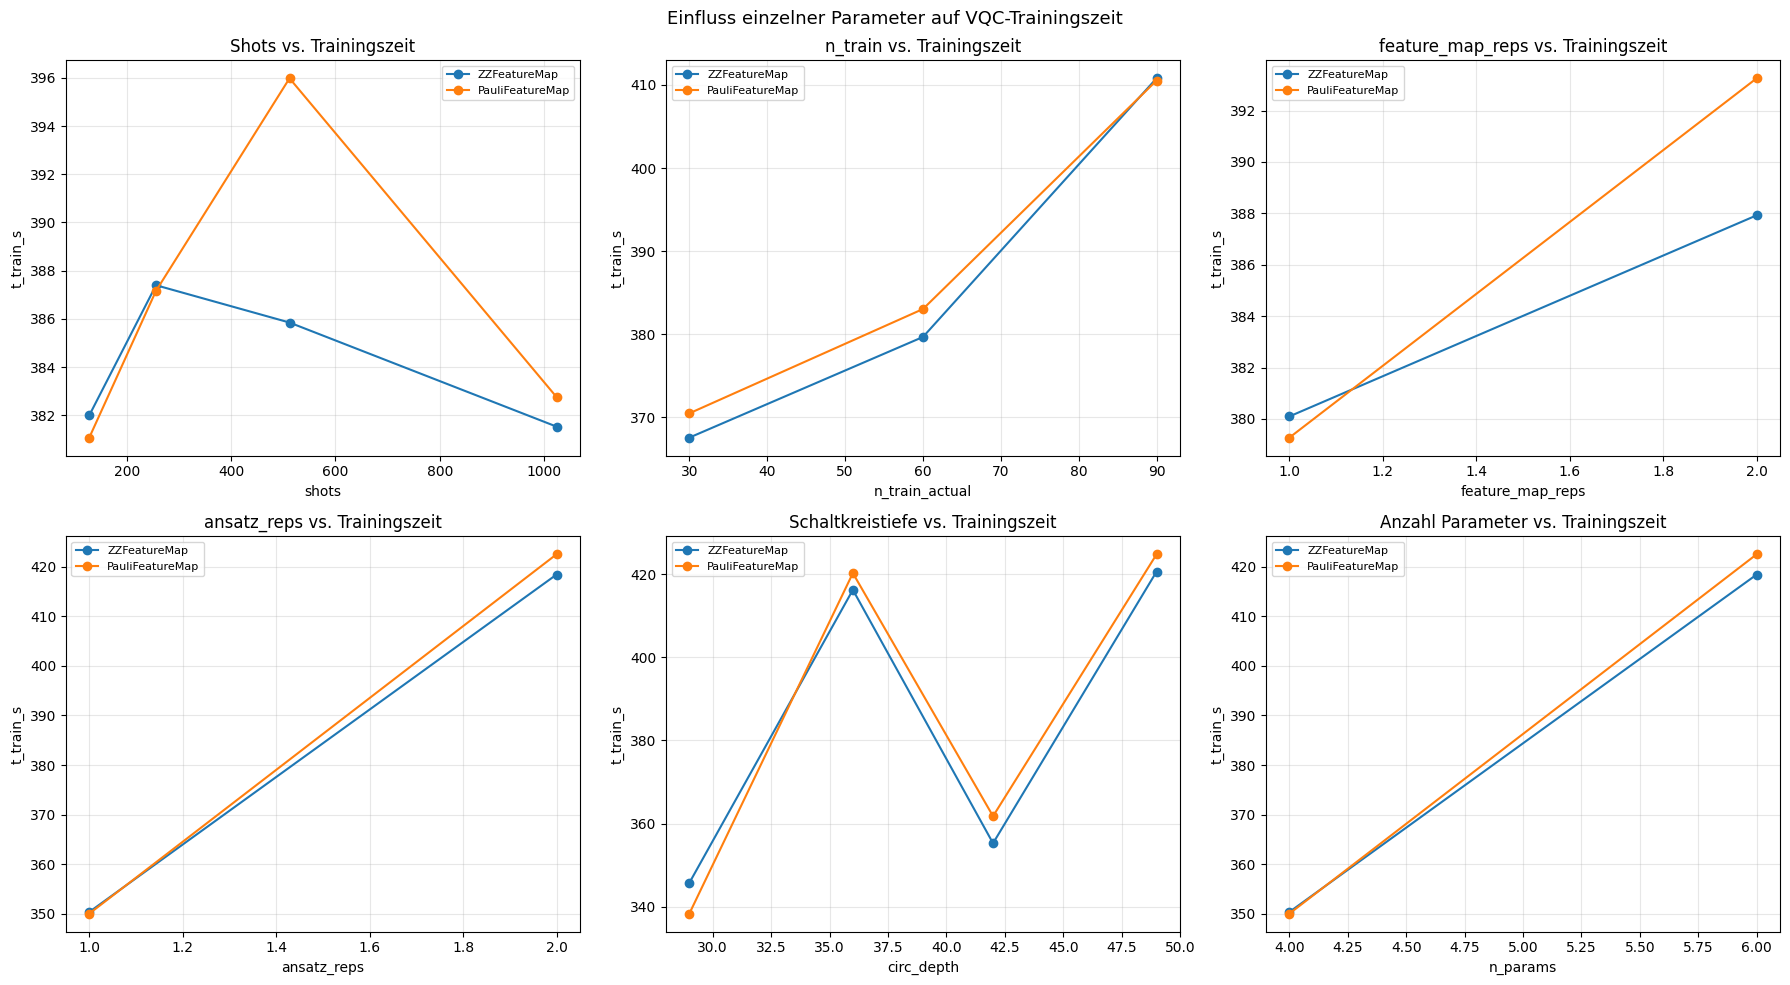

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Einfluss einzelner Parameter auf VQC-Trainingszeit', fontsize=13)

plot_params = [
    ('shots',            't_train_s',    'Shots vs. Trainingszeit'),
    ('n_train_actual',   't_train_s',    'n_train vs. Trainingszeit'),
    ('feature_map_reps', 't_train_s',    'feature_map_reps vs. Trainingszeit'),
    ('ansatz_reps',      't_train_s',    'ansatz_reps vs. Trainingszeit'),
    ('circ_depth',       't_train_s',    'Schaltkreistiefe vs. Trainingszeit'),
    ('n_params',         't_train_s',    'Anzahl Parameter vs. Trainingszeit'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, plot_params):
    for fm in df_ok['feature_map'].unique():
        subset  = df_ok[df_ok['feature_map'] == fm]
        grouped = subset.groupby(x_col)[y_col].mean()
        ax.plot(grouped.index, grouped.values, marker='o', label=fm)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vqc_analyse_laufzeit.png', dpi=150, bbox_inches='tight')
plt.show()

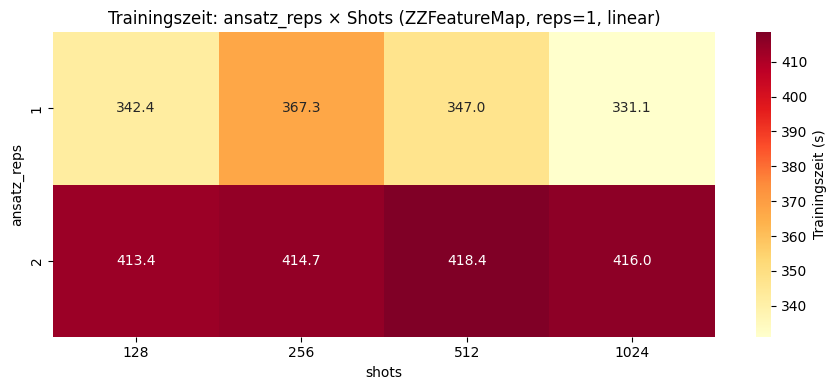

In [10]:
# Heatmap: ansatz_reps x shots -> Trainingszeit (ZZFeatureMap, reps=1, linear)
subset = df_ok[
    (df_ok['feature_map'] == 'ZZFeatureMap') &
    (df_ok['feature_map_reps'] == 1) &
    (df_ok['entanglement'] == 'linear')
]
if not subset.empty:
    pivot = subset.pivot_table(
        index='ansatz_reps', columns='shots',
        values='t_train_s', aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                cbar_kws={'label': 'Trainingszeit (s)'}, ax=ax)
    ax.set_title('Trainingszeit: ansatz_reps × Shots (ZZFeatureMap, reps=1, linear)')
    plt.tight_layout()
    plt.savefig('vqc_analyse_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9 - Schaltkreis-Analyse

In [11]:
print('=== Schaltkreistiefe nach Feature Map, reps und entanglement ===')
print(df_ok.groupby(['feature_map', 'feature_map_reps', 'ansatz_reps', 'entanglement'])[
    ['circ_depth', 'gate_count', 'n_params']
].mean().round(1))

print('\n=== Korrelation: Schaltkreistiefe vs. Trainingszeit ===')
print(df_ok[['circ_depth', 'gate_count', 'n_params', 't_train_s', 't_transpile_s']].corr().round(3))

=== Schaltkreistiefe nach Feature Map, reps und entanglement ===
                                                           circ_depth  \
feature_map     feature_map_reps ansatz_reps entanglement               
PauliFeatureMap 1                1           circular            29.0   
                                             full                29.0   
                                             linear              29.0   
                                 2           circular            36.0   
                                             full                36.0   
                                             linear              36.0   
                2                1           circular            42.0   
                                             full                42.0   
                                             linear              42.0   
                                 2           circular            49.0   
                                             full          

## 10 - Vorhersagegüte

In [12]:
print('=== Güte nach Feature Map und entanglement ===')
print(df_ok.groupby(['feature_map', 'entanglement'])[
    ['accuracy', 'f1_score', 'precision', 'recall']
].mean().round(4))

print('\n=== Güte nach shots ===')
print(df_ok.groupby('shots')[['accuracy', 'f1_score']].mean().round(4))

print('\n=== Güte nach ansatz_reps ===')
print(df_ok.groupby('ansatz_reps')[['accuracy', 'f1_score']].mean().round(4))

=== Güte nach Feature Map und entanglement ===
                              accuracy  f1_score  precision  recall
feature_map     entanglement                                       
PauliFeatureMap circular        0.4199    0.3367     0.2869  0.4199
                full            0.4155    0.3325     0.2833  0.4155
                linear          0.4171    0.3345     0.2852  0.4171
ZZFeatureMap    circular        0.4107    0.3285     0.2799  0.4107
                full            0.4135    0.3313     0.2818  0.4135
                linear          0.4314    0.3512     0.3046  0.4318

=== Güte nach shots ===
       accuracy  f1_score
shots                    
128      0.4139    0.3332
256      0.4223    0.3407
512      0.4133    0.3309
1024     0.4232    0.3391

=== Güte nach ansatz_reps ===
             accuracy  f1_score
ansatz_reps                    
1              0.4140    0.3334
2              0.4225    0.3386


## 11 - Beste Konfiguration identifizieren

Kriterium: Minimale Trainingszeit bei Accuracy >= 0.70.

In [21]:
MIN_ACCURACY = 0.57

df_filtered = df_ok[df_ok['accuracy'] >= MIN_ACCURACY].sort_values('t_train_s')

cols = [
    'datensatz', 'n_train_actual', 'feature_map', 'feature_map_reps',
    'ansatz_reps', 'entanglement', 'shots', 'optimization_level',
    'circ_depth', 'n_params', 'accuracy', 'f1_score', 't_train_s', 't_gesamt_s'
]

print(f'Konfigurationen mit Accuracy >= {MIN_ACCURACY}: {len(df_filtered)}')
print(f'\nTop 10 schnellste:')
print(df_filtered[cols].head(10).to_string(index=False))

if len(df_filtered) > 0:
    beste = df_filtered.iloc[0]
    print(f'\n=== EMPFOHLENE KONFIGURATION FÜR HARDWARE-EXPERIMENT ===')
    for col in cols:
        print(f'  {col}: {beste[col]}')

Konfigurationen mit Accuracy >= 0.57: 2

Top 10 schnellste:
datensatz  n_train_actual     feature_map  feature_map_reps  ansatz_reps entanglement  shots  optimization_level  circ_depth  n_params  accuracy  f1_score  t_train_s  t_gesamt_s
     Iris              60    ZZFeatureMap                 2            2         full   1024                   1          49         6    0.5778    0.4702   419.1592    427.9306
     Iris              90 PauliFeatureMap                 1            2     circular    512                   1          36         6    0.5778    0.4702   451.6104    459.8003

=== EMPFOHLENE KONFIGURATION FÜR HARDWARE-EXPERIMENT ===
  datensatz: Iris
  n_train_actual: 60
  feature_map: ZZFeatureMap
  feature_map_reps: 2
  ansatz_reps: 2
  entanglement: full
  shots: 1024
  optimization_level: 1
  circ_depth: 49
  n_params: 6
  accuracy: 0.5778
  f1_score: 0.4702
  t_train_s: 419.1592
  t_gesamt_s: 427.9306


## 12 - Vollständige Ergebnistabelle

In [ ]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', '{:.4f}'.format)

df.sort_values([
    'datensatz', 'n_train_soll', 'feature_map',
    'feature_map_reps', 'ansatz_reps', 'entanglement', 'shots'
])

## 13 - Gezielter Vergleich: optimization_level

Erst nach Abschnitt 11 ausführen - nutzt die beste Konfiguration.
Testet ob optimization_level 0/2/3 gegenüber Standard (1) einen Unterschied macht.

In [ ]:
# Beste Konfiguration aus Abschnitt 11 hier eintragen
BESTE_CONFIG = {
    'datensatz':        'Iris',          # anpassen
    'n_train':          30,              # anpassen
    'feature_map':      'ZZFeatureMap',  # anpassen
    'feature_map_reps': 1,               # anpassen
    'ansatz_reps':      1,               # anpassen
    'entanglement':     'linear',        # anpassen
    'shots':            256,             # anpassen
}

opt_combinations = [
    {**BESTE_CONFIG, 'optimization_level': ol}
    for ol in [0, 1, 2, 3]
]

print(f'optimization_level Vergleich: {len(opt_combinations)} Läufe')
print('Starte...\n')

results_opt = []
for i, params in enumerate(opt_combinations):
    print(f'[{i+1}/{len(opt_combinations)}] opt_level={params["optimization_level"]}')
    try:
        result = run_experiment(params, lauf_nr=i + 1)
        print(f'  t_train: {result["t_train_s"]}s | t_transpile: {result["t_transpile_s"]}s | Acc: {result["accuracy"]:.4f}')
        results_opt.append(result)
    except Exception as e:
        print(f'  FEHLER: {e}')

df_opt = pd.DataFrame(results_opt)
df_opt.to_csv('ergebnisse_vqc_optlevel_vergleich.csv', index=False)

print('\n=== Ergebnis: optimization_level Vergleich ===')
print(df_opt[[
    'optimization_level', 't_transpile_s', 't_train_s',
    'circ_depth', 'gate_count', 'n_params', 'accuracy'
]].to_string(index=False))

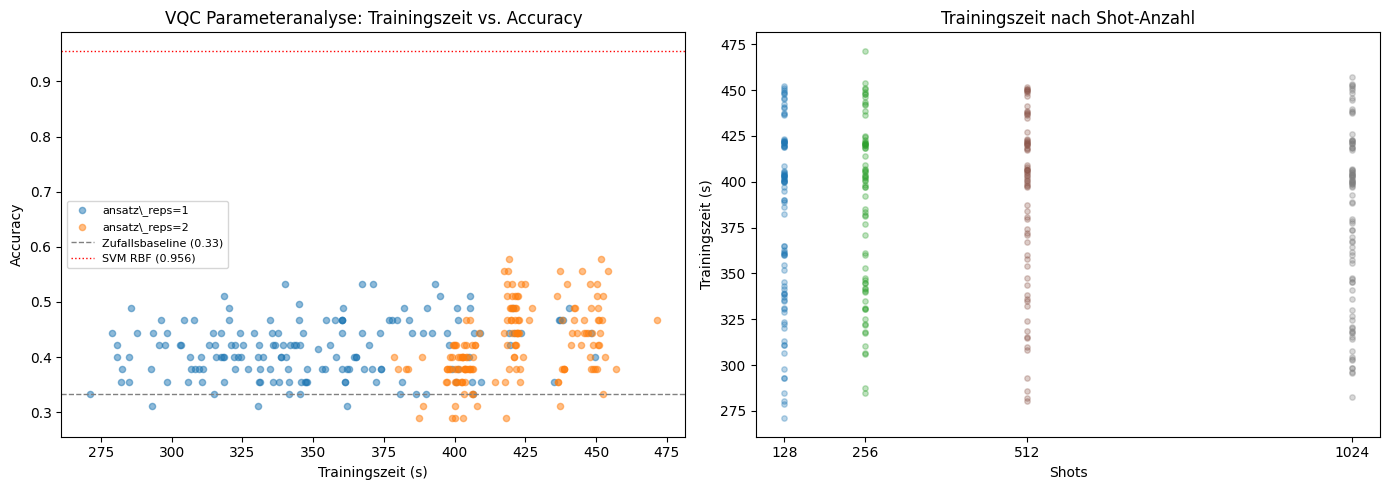

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv('Ergebnisse/ergebnisse_vqc_parameter_analyse.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Trainingszeit vs. Accuracy, eingefärbt nach ansatz_reps ---
colors = {1: '#1f77b4', 2: '#ff7f0e'}
for reps, grp in df.groupby('ansatz_reps'):
    axes[0].scatter(
        grp['t_train_s'], grp['accuracy'],
        c=colors[reps], alpha=0.5, s=20,
        label=f'ansatz\\_reps={reps}'
    )

axes[0].axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Zufallsbaseline (0.33)')
axes[0].axhline(0.9556, color='red', linestyle=':', linewidth=1, label='SVM RBF (0.956)')
axes[0].set_xlabel('Trainingszeit (s)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('VQC Parameteranalyse: Trainingszeit vs. Accuracy')
axes[0].legend(fontsize=8)

# --- Plot 2: Trainingszeit-Verteilung nach shots ---
shot_vals = sorted(df['shots'].unique())
for i, s in enumerate(shot_vals):
    grp = df[df['shots'] == s]['t_train_s']
    axes[1].scatter(
        [s] * len(grp), grp,
        alpha=0.3, s=15, color=cm.tab10(i / len(shot_vals))
    )

axes[1].set_xlabel('Shots')
axes[1].set_ylabel('Trainingszeit (s)')
axes[1].set_title('Trainingszeit nach Shot-Anzahl')
axes[1].set_xticks(shot_vals)

plt.tight_layout()
plt.savefig('vqc_parameteranalyse_scatter.pdf', bbox_inches='tight', dpi=300)
plt.savefig('vqc_parameteranalyse_scatter.png', bbox_inches='tight', dpi=300)
plt.show()